<h1><center>Laboratorio 7: Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Otoño 2025</strong></center>

### Cuerpo Docente:

- Profesores: Stefano Schiappacasse, Sebastián Tinoco
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Angelo Muñoz, Valentina Zúñiga

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1:Sasha Oyanadel
- Nombre de alumno 2:Pablo Vergara


### **Link de repositorio de GitHub:** [Insertar Repositorio] https://github.com/locoplayafeincut/laboratorios-labcsdatos-/blob/main/lab7/Lab7_enunciado.ipynb

### Indice

1. [Temas a tratar](#Temas-a-tratar:)
3. [Descripcción del laboratorio](#Descripción-del-laboratorio.)
4. [Desarrollo](#Desarrollo)

## Temas a tratar

- Clasificación usando `XGBoost`.
- Métodos Agnósticos Globales de Interpretabilidad (`Partial Dependence Plot`, `Permutation Feature Importance`)
- Métodos Agnósticos Locales de Interpretabilidad (`Scoped Rules`, `SHAP`)

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: 6 días de plazo con descuento de 1 punto por día. Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda fuertemente asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.


### Objetivos principales del laboratorio

- Generar un pipeline de clasificación con `XGBoost`.
- Implementar modelos de interpretabilidad para explicar el funcionamiento del modelo de clasificación.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# 1. Problemas Clínicos del Dr. Simi

<p align="center">
  <img src="https://gantz.cl/wp-content/uploads/2020/01/79024136_2718114448239059_7240913062570491904_o.jpg" width="350">
</p>

El reconocido **Dr. Simi**, famoso vendedor de medicamentos en latinoamerica, debido a la creciente prevalencia de enfermedades crónicas, como la diabetes, decidió abrir una clínica especializada en el tratamiento de esta enfermedad en nuestro país.

La clínica del Doctor Simi se convirtió en un lugar donde los pacientes con diabetes podrían recibir atención médica integral. El personal médico estaba compuesto por especialistas en endocrinología, nutrición y enfermería, todos capacitados en el manejo de la diabetes.

Sin embargo él se ha dado cuenta que los tiempos han cambiado y gracias a las tecnologías es posible generar mejores predicciones en la diabetes conociendo el historial médico de las personas. Por esto, el doctor se ha colocado una meta de incluir modelos de machine learning dentro de sus clínicas, para ello le ha solicitado crear un modelo capaz de predecir/clasificar diabetes pero le rogó que el desarrollo del modelo tuviera un especial enfoque en la interpretabilidad de lo que hace su modelo.

Para que usted pueda entrenar el modelo, Dr. Simi le ha entregado un dataset de todos los clientes que fueron detectados con diabetes a lo largo de la historia de la clinica. Con ello, adjunta el historial médico de las personas en forma de datos tabulares para que usted pueda realizar fácilmente la clasificación.


In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('diabetes_data.csv')
df.head(5)

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Clasificación de pacientes con diabetes (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/QH--g3ZaSbsAAAAC/dr-simi-abrazo.gif" width="400">
</p>

Tareas:
1. En primer lugar, el reconocido doctor le pide entrenar un modelo de `XGBoost` utilizando como target la columna `Diabetes` del dataset `diabetes_data.csv`. Para el entrenamiento, realice los siguientes pasos:
  * Realice una breve exploración de los datos y determine si aplicará transformaciones (MinMaxScaler, StandardScaler, etc.) en alguna/s de las variables. (1 punto)
  * Cree un conjunto de entrenamiento y uno de prueba, con una proporción de 1/3 en el conjunto de prueba. (0.5 puntos)
  * Cree un ColumnTransformer de preprocesamiento donde aplique las transformaciones determinadas anteriormente. Fije el parámetro `verbose_feature_names_out=False` y fije la salida del ColumnTransformer en formato pandas mediante el método `.set_output(transform='pandas')`. (1 punto)
  *  Cree un pipeline donde integre el preprocesamiento y el modelo `XGBoost` y entrene el modelo. Luego utilice `classification_report(..)` para reportar el desempeño del modelo. (1 punto)

Comente sus decisiones y los resultados obtenidos con el modelo.

2. Luego, le pide responder las siguientes preguntas:
  *  ¿Es acaso un buen predictor de diabetes? (0.5 puntos)
  * ¿Qué buscan explicar las métricas utilizadas? (0.5 puntos)
  * ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?(0.5 puntos)

In [2]:
!pip install xgboost


[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


Primeras filas del dataset:
    Age  Sex  HighChol  CholCheck   BMI  Smoker  HeartDiseaseorAttack  \
0   4.0  1.0       0.0        1.0  26.0     0.0                   0.0   
1  12.0  1.0       1.0        1.0  26.0     1.0                   0.0   
2  13.0  1.0       0.0        1.0  26.0     0.0                   0.0   
3  11.0  1.0       1.0        1.0  28.0     1.0                   0.0   
4   8.0  0.0       0.0        1.0  29.0     1.0                   0.0   

   PhysActivity  Fruits  Veggies  HvyAlcoholConsump  GenHlth  MentHlth  \
0           1.0     0.0      1.0                0.0      3.0       5.0   
1           0.0     1.0      0.0                0.0      3.0       0.0   
2           1.0     1.0      1.0                0.0      1.0       0.0   
3           1.0     1.0      1.0                0.0      3.0       0.0   
4           1.0     1.0      1.0                0.0      2.0       0.0   

   PhysHlth  DiffWalk  Stroke  HighBP  Diabetes  
0      30.0       0.0     0.0     1.0 

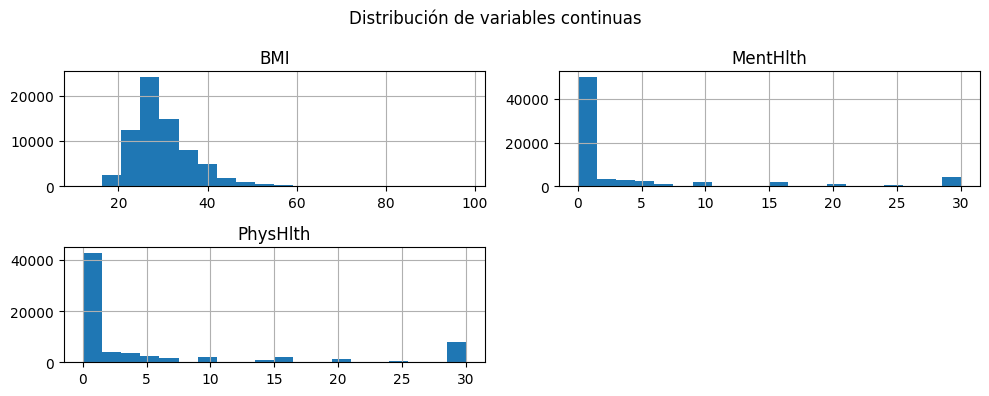

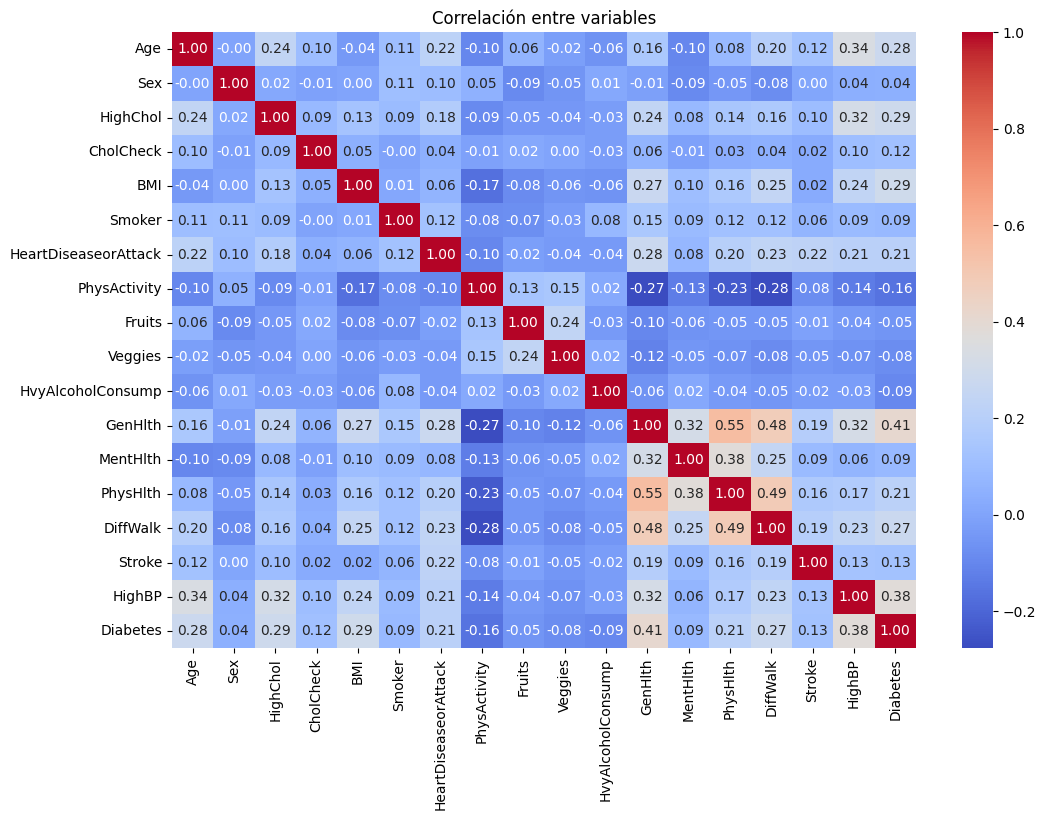

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#1) 

# Cargar el dataset
df = pd.read_csv("diabetes_data.csv")

# Vista general
print("Primeras filas del dataset:")
print(df.head())

print("\nResumen estadístico:")
print(df.describe())

print("\nValores únicos por columna:")
print(df.nunique())

print("\nValores faltantes por columna:")
print(df.isna().sum())

# Separación tentativa por tipo de variable
# Consideramos numéricas continuas: BMI, MentHlth, PhysHlth
num_cont = ["BMI", "MentHlth", "PhysHlth"]

# Age es ordinal codificado (0 a 13)
# Las demás son binarias o categóricas discretas ya codificadas
cat_ordinal = [col for col in df.columns if col not in num_cont + ["Diabetes"]]

# Visualizaciones básicas
# Histograma de variables numéricas
df[num_cont].hist(bins=20, figsize=(10, 4))
plt.suptitle("Distribución de variables continuas")
plt.tight_layout()
plt.show()

# Heatmap de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlación entre variables")
plt.show()



---
Variables numéricas continuas o discretas amplias:
Estas tienen muchos valores distintos y representan cantidades reales. Requieren escalamiento para que el modelo no se sesgue por su magnitud.

-  BMI (80 valores únicos)

-  MentHlth (31 valores únicos)

-  PhysHlth (31 valores únicos)

        Para estas variables usaremos StandardScaler

---

Variables categóricas binarias o ordinales:
Tienen pocos valores únicos, ya codificadas como 0/1 o en pequeños rangos ordinales. No se escalan.

- Binarias (0/1): Sex, HighChol, CholCheck, Smoker, HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, DiffWalk, Stroke, HighBP

- Ordinales codificadas:

- Age (13 tramos codificados → no escalar, pero puede usarse tal cual)

- GenHlth (escala 1–5)

        Para estas variables usaremos passthrough

---

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# 2) 

X = df.drop("Diabetes", axis=1)
y = df["Diabetes"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42, stratify=y)

# 3)

num_features = ["Age", "BMI", "MentHlth", "PhysHlth"]
cat_features = [col for col in X.columns if col not in num_features]

#Preprocesamiento con ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", "passthrough", cat_features)
], verbose_feature_names_out=False)

preprocessor.set_output(transform="pandas")

# 4) Crear pipeline con XGBoost

clf = Pipeline([
    ("pre", preprocessor),
    ("model", XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ))
])


clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=3))


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [12:21:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Classification Report ===
              precision    recall  f1-score   support

         0.0      0.769     0.703     0.734     11782
         1.0      0.726     0.788     0.756     11782

    accuracy                          0.746     23564
   macro avg      0.748     0.746     0.745     23564
weighted avg      0.748     0.746     0.745     23564



---
# ¿Es acaso un buen predictor de diabetes? (0.5 puntos)

Si, el modelo es una buena base para un buen predictor de diabetes, dado que mantiene un accuracy de 0.746 y un f1 de 0.756 para la clase positiva haciendo un buen balance entre precision y recall además muestra un desempeño similar para ambas clases.

---
# ¿Qué buscan explicar las métricas utilizadas? (0.5 puntos)

* Precision: mide la exactitud de las predicciones positivas. En este caso, de los que el modelo predijo como diabéticos, un 72.6% realmente lo eran.

* Recall: indica qué porcentaje de los verdaderos casos de diabetes fueron detectados por el modelo. Aquí fue de 78.8%, lo cual es muy importante en salud, ya que prioriza no dejar casos sin detectar.

* F1-score: balance entre precisión y recall; útil cuando hay cierto desbalance o cuando ambos errores (falsos positivos y negativos) importan.

* Accuracy: proporción global de aciertos.

---

# ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?(0.5 puntos)

No necesariamente, las metricas no nos dan una idea de que features utiliza, evaluan unicamente el rendimiento, por lo cual si deseamos ver esto habria que usar 
herramientas como la importancia de las caracteristicas o SHAP.

---

## 3. Importancia de las features con XGBoost (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/5JAj5_IiagEAAAAd/dr-simi-dr-simi-dance.gif" width="400">
</p>

Tareas:
1. Para añadir el toque de interpretabilidad que Dr. Simi le pide, se le pide calcular la **importancia de las features** del modelo entrenado utilizando todos los métodos (*weight*, *cover*, *gain*) que posee xgboost usando `plot_importance`. `Hint:` Puede acceder a un paso de un pipeline por su nombre mediante el método `.named_steps[...]` (3 puntos)
2. ¿Los resultados obtenidos con los diferentes métodos son compatibles?, comente sus resultados y a que se debe la igualdad o desigualdad que ve en los resultados. (1 punto)
3. Finalmente, ¿las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método? (1 punto)

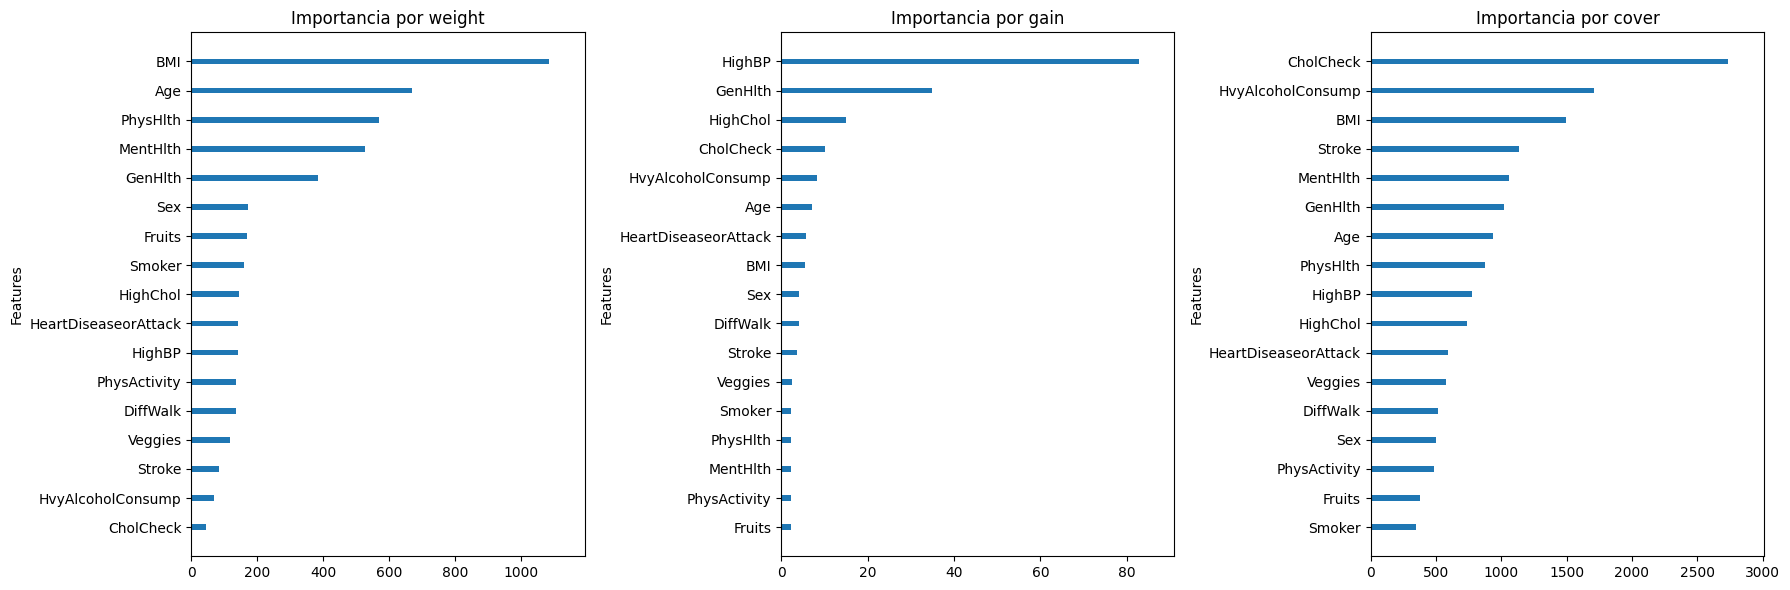

In [5]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

#1) 

# Extraer el modelo XGBoost desde el pipeline
xgb_model = clf.named_steps["model"]

# Crear figura para los tres métodos 
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Métodos: weight, gain, cover
for ax, importance_type in zip(axs, ["weight", "gain", "cover"]):
    plot_importance(
        xgb_model,
        importance_type=importance_type,
        ax=ax,
        title=f"Importancia por {importance_type}",
        show_values=False,
        grid=False
    )
    ax.set_xlabel("")

plt.tight_layout()
plt.show()


---
### ¿Los resultados obtenidos con los diferentes métodos son compatibles?, comente sus resultados y a que se debe la igualdad o desigualdad que ve en los resultados. (1 punto)
No son completamente compatibles ya qu cada metrica mide un aspecto distinto del uso de las variables, por un lado tenemos Weight que sus variables principales son BMI, Age, PhysHlth, MentHlth	Estas se usaron más veces para hacer splits. Mientras que en Gain se usaron	HighBP, GenHlth, HighChol	las cuales aportaron mayor mejora promedio en precisión y por ultimo Cover utilizó	CholCheck, HvyAlcoholConsump, BMI y dividieron más muestras al ser usadas

---

### ¿las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método? (1 punto)

No del todo. tiene distintas ventajas como que permite identifiar que variables influyen más en terminos globales y ayudan a realizar una selección de caracteristicas informada. Por otro lado sus debilidades es que no muestran como una variable influye, solo dice que influye, no explica casos individuales que pueden ser utiles para distintos paciente y no considera interacciones entre las variables.

---

## 4. Métodos Agnósticos Globales (10 puntos)

<p align="center">
  <img src="https://media.tenor.com/JcRHtjVuXN8AAAAC/dr-simi-farmacias-similares.gif" width="400">
</p>

Tareas:
1. Para mitigar los problemas encontrados en la sección anterior, Dr. Simi le pide implementar un **método de permutación** que le permita observar la importancia de las features. `Nota:`Tenga cuidado con el orden de las columnas de este método. `Hint:` Puede obtener los features del clasificador con su respectivo orden mediante el método `.get_booster().feature_names` (2 puntos)
2. Para que su modelo sea consistente, repita el proceso **30 veces** y verifique la desviación estándar de sus resultados (¿Qué señala esta?). (2 puntos)
3. Visualice los resultados de este método en un gráfico. (2 puntos)
4. Además, responda las siguientes preguntas:
  - ¿Cómo mide la importancia de las features su propuesta? (1 punto)
  - ¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido? (1 punto)
  - ¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior? (1 punto)
  - Nombre y explique 3 ventajas y 3 desventajas del método implementado. (1 punto)

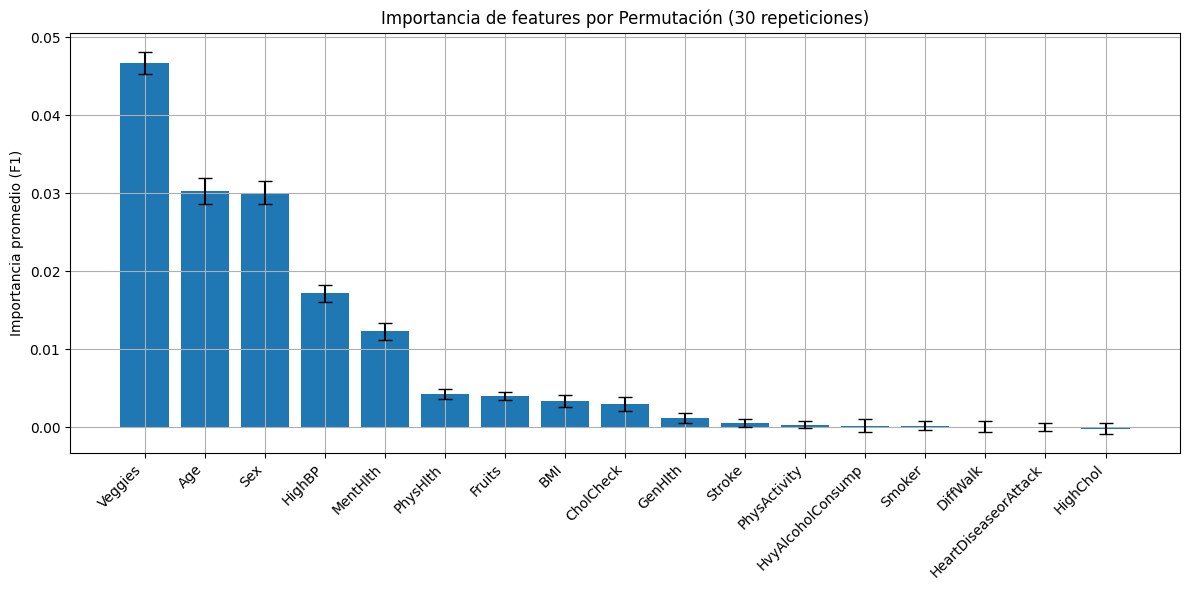

Veggies              | Media: 0.0467 | Std: 0.0014
Age                  | Media: 0.0303 | Std: 0.0017
Sex                  | Media: 0.0301 | Std: 0.0014
HighBP               | Media: 0.0172 | Std: 0.0011
MentHlth             | Media: 0.0123 | Std: 0.0011
PhysHlth             | Media: 0.0043 | Std: 0.0006
Fruits               | Media: 0.0040 | Std: 0.0006
BMI                  | Media: 0.0034 | Std: 0.0007
CholCheck            | Media: 0.0030 | Std: 0.0009
GenHlth              | Media: 0.0013 | Std: 0.0007
Stroke               | Media: 0.0006 | Std: 0.0005
PhysActivity         | Media: 0.0003 | Std: 0.0005
HvyAlcoholConsump    | Media: 0.0002 | Std: 0.0008
Smoker               | Media: 0.0002 | Std: 0.0006
DiffWalk             | Media: 0.0001 | Std: 0.0007
HeartDiseaseorAttack | Media: 0.0001 | Std: 0.0005
HighChol             | Media: -0.0002 | Std: 0.0007


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# 1) Asegurar que las features estén en el orden correcto
feature_names = clf.named_steps["model"].get_booster().feature_names

# 2) Repetir permutación 30 veces 
importancias = []

for seed in range(30):
    result = permutation_importance(
        clf, X_test, y_test,
        n_repeats=1,  # una vez por seed (ya repetimos en el loop)
        random_state=seed,
        scoring="f1",  # puede ser f1 o accuracy
        n_jobs=-1
    )
    importancias.append(result.importances_mean)

importancias = np.array(importancias)  # shape: (30, n_features)
mean_importance = np.mean(importancias, axis=0)
std_importance = np.std(importancias, axis=0)

# 3) Visualizar
sorted_idx = np.argsort(mean_importance)[::-1]
plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_names)), mean_importance[sorted_idx],
        yerr=std_importance[sorted_idx], capsize=5)
plt.xticks(range(len(feature_names)), np.array(feature_names)[sorted_idx], rotation=45, ha='right')
plt.ylabel("Importancia promedio (F1)")
plt.title("Importancia de features por Permutación (30 repeticiones)")
plt.tight_layout()
plt.grid(True)
plt.show()
    # Imprimir tabla ordenada por importancia promedio
for i in sorted_idx:
    print(f"{feature_names[i]:<20} | Media: {mean_importance[i]:.4f} | Std: {std_importance[i]:.4f}")


---

### ¿Qué señala la desviación estándar de los resultados? (2 puntos)
La desviación estándar indica qué tan estables son las importancias estimadas de cada variable a lo largo de las 30 permutaciones.

Una baja desviación estándar indica que el impacto de la feature en el rendimiento del modelo es consistente y robusto, como ocurre con Veggies (std = 0.0014).

Una alta desviación estándar indica que la importancia de la feature fluctúa, probablemente porque su efecto depende del azar, de interacciones o simplemente es poco relevante.

---


### ¿Cómo mide la importancia de las features este método? (1 punto)
Este método mide la importancia de una feature cuantificando la caída del rendimiento del modelo (F1-score) cuando esa variable es permutada aleatoriamente.
Si al desordenar una variable el rendimiento cae mucho, significa que el modelo dependía de esa variable para tomar decisiones correctas.
Este enfoque es modelo-agnóstico, ya que no depende de cómo el modelo fue entrenado, sino de su desempeño real al hacer predicciones.

### ¿Qué features tienen mayor impacto? ¿Tienen sentido? (1 punto)
Las features con mayor impacto con Veggies, Age, Sex, Highbp y MentHlth. si tiene sentido, a mayor edad es más probable tener diabetes o no, y una dieta vegetariana puede mejorar la calidad de vida de una persona, por lo cual tendría sentido. El sexo podría ser influyente o no, no contamos con el conocimiento medico para corroborar si esto es real o no. la hipertesión es un factor de riesgo a la diabetes y la salud mental puede influir en el estilo de vida del paciente.

---

### ¿Cómo cambian las conclusiones respecto a feature_importance del modelo anterior?

Las conclusiones cambian significativamente en los métodos de XGBoost (weight, gain, cover), destacaban variables como BMI, HighBP, y GenHlth, con la permutación, en cambio, Veggies, Age y Sex resultaron ser las variables más críticas, y BMI perdió relevancia.

Esto sugiere que el modelo usaba mucho ciertas variables (como BMI), pero no necesariamente eran las que más contribuían al desempeño global.
El método de permutación evalúa impacto real en predicción, no solo frecuencia de uso.

--- 

###  3 ventajas y 3 desventajas del método de permutación (1 punto)
Dentro de las ventajas se cuentra que el funciona con cualquier tipo de modelo, no solo árboles. además permite una medición directa del impacto y incluye interaciones implicitas ya que refleja el efecto dentro del contexto del modelo completo.

En las desventajas encontramos su costo computacional, dado que requiere multiples evaluaciones, su sensibilidad al azar, dado que si no se repite varias veces pueden variar mucho los resutados y no mide la dierrecionalidad es decir on indica si la variable aumenta o reduce la posobilidad de clase positiva.

---

## 5. Métodos Agnósticos Locales (20 puntos)

<p align="center">
  <img src="https://i.makeagif.com/media/10-24-2024/oMCrLI.gif" width="400">
</p>

### 5.1 Calculando Shap Values (4 puntos)

Tareas:
1. Alegre por saber cómo funciona el modelo de predicción a nivel general, Dr. Simi le pide ahora interpretar las predicciones de su modelo a nivel de paciente (es decir, desde un punto de vista **local**). Para esto, el ilustre farmacéutico le pide calcular los *shap values* de su modelo. (2 puntos)
2. ¿Qué representa cada número en su resultado? (1 punto)
3. ¿Es posible atribuir un significado a la positividad/negatividad de cada valor? (1 punto)

In [7]:
!pip install shap


[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [8]:
import warnings
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")

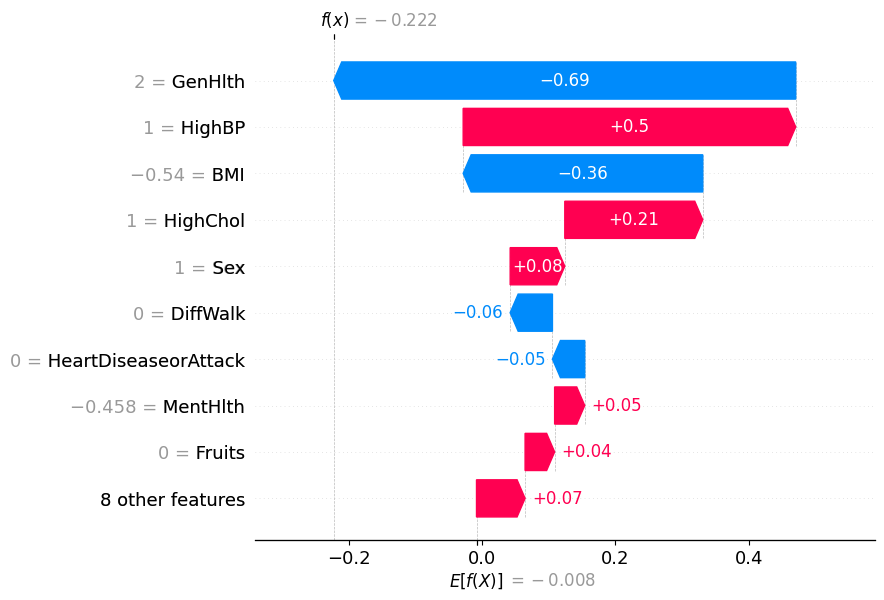

In [9]:
import shap

# 1) 

# Extraer X preprocesado
X_test_proc = clf.named_steps["pre"].transform(X_test)

# Crear el explainer de SHAP
explainer = shap.Explainer(clf.named_steps["model"])
shap_values = explainer(X_test_proc)

# Elegimos un paciente (ej: índice 0)
idx = 0
shap.plots.waterfall(shap_values[idx])


---

### ¿Qué representa cada número en el resultado de SHAP? (1 punto)
Cada número indica la contribución específica de una variable al valor final de predicción del modelo para un paciente dado. Por ejemplo GenHlth = 2 aporta –0.69 → esta característica disminuyó fuertemente la probabilidad de diabetes en este paciente. Mientras que HighBP = 1 aporta +0.50 → esta característica aumentó fuertemente la probabilidad.
Estos valores son aditivos, por lo cual el modelo parte desde una base E[f(X)]= -0.008 y suma o resta cada feature hasta llegar hasta -0.222, el valor finla para este paciente.

---

### ¿Es posible atribuir un significado a la positividad/negatividad de cada valor? (1 punto)
Si, se puede, un Shap negativo indica que la variable reduce la posiblidad de que el paciente tenga diabetes, mientras que un shap positiva indica que aumenta la probabilidad de la clase 1.

---

### 5.2 Aporte local (4 puntos)

1. Usando los *shap values* calculados, grafique el **aporte local** de las diferentes variables para las instancias **1**, **9** y **150** (1 punto).

2. Interprete sus resultados y responda:

  - ¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes? (1 punto)

  - ¿Existe algún patrón común entre las instancias analizadas? (1 punto)

  - ¿Es posible generalizar estas conclusiones a todo el dataset? (1 punto)

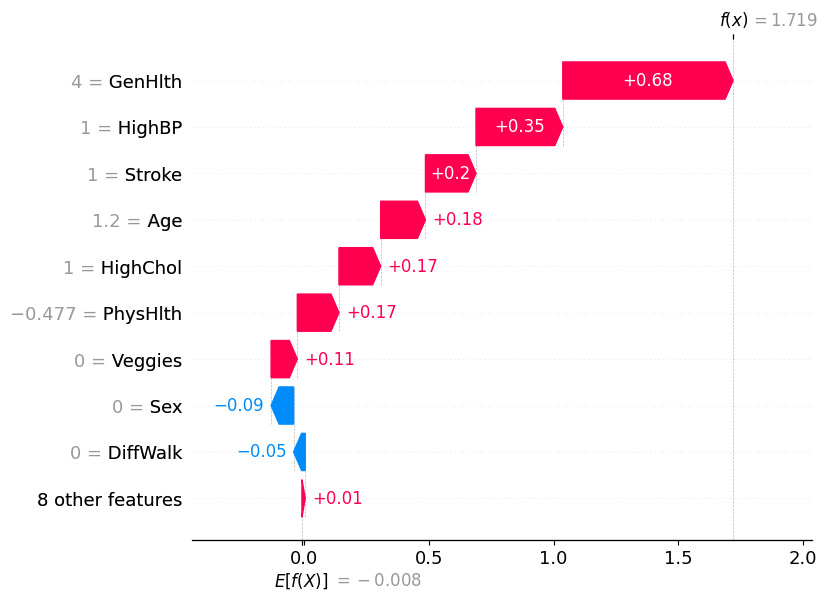

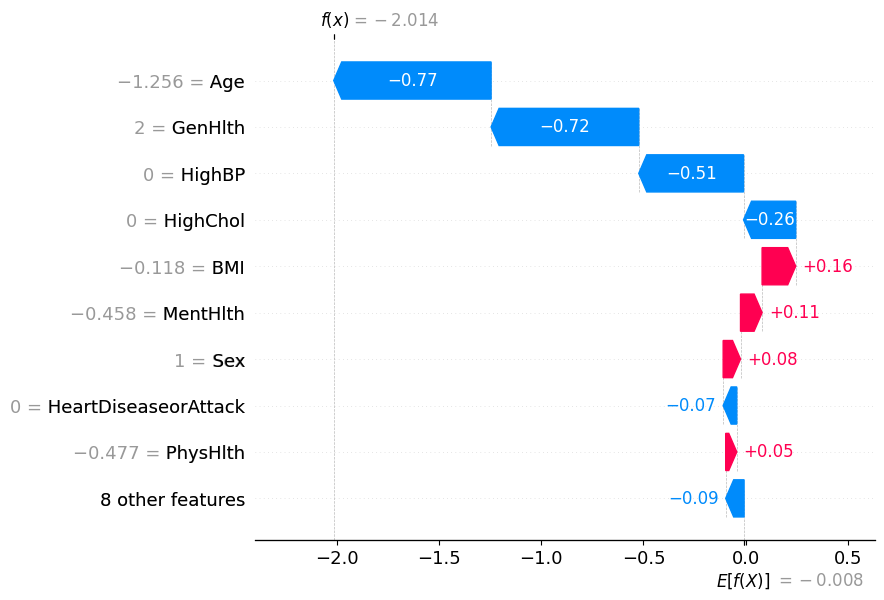

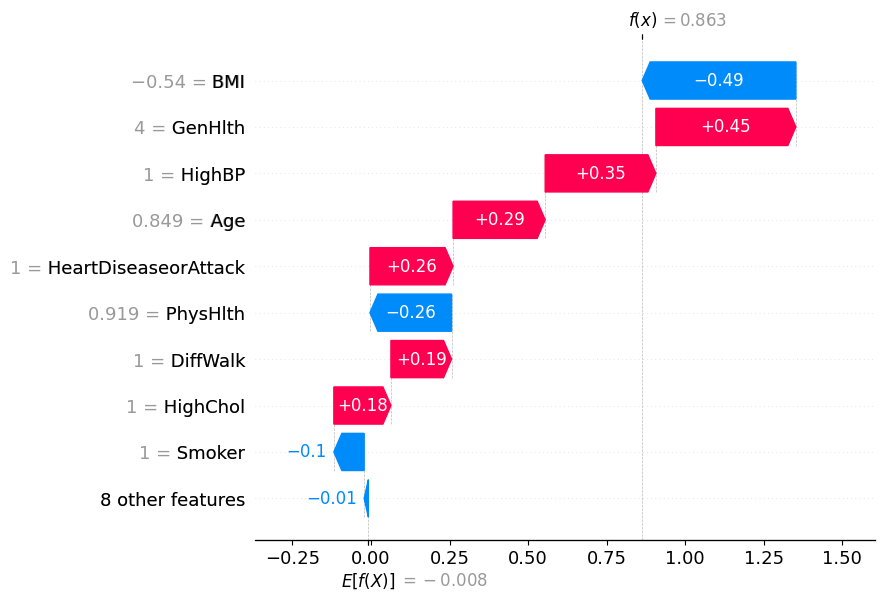

In [19]:
#1)

# Visualización de pacientes específicos con SHAP
shap.plots.waterfall(shap_values[1])
shap.plots.waterfall(shap_values[9])
shap.plots.waterfall(shap_values[150])

---

## Interpretación Local con SHAP para Instancias 1, 9 y 150

---

### ¿Qué variables afectan de manera positiva o negativa a la probabilidad de poseer diabetes? (1 punto)

A partir de los gráficos de SHAP para los pacientes 1, 9 y 150:

####  Variables que **aumentan** la probabilidad de diabetes (`SHAP > 0`)
- `HighBP = 1` → presión alta, presente en los tres casos con fuerte impacto positivo.
- `GenHlth = 4` o mayor → mala salud general autopercibida, gran contribuyente positivo.
- `HighChol = 1` → colesterol alto, presente en todos los pacientes con efecto positivo.
- `Age` elevado → consistentemente aumenta la probabilidad.
- `Stroke = 1`, `HeartDiseaseorAttack = 1` → aparecen como factores de riesgo adicionales en casos específicos.

####  Variables que **reducen** la probabilidad de diabetes (`SHAP < 0`)
- `PhysHlth` (mejor salud física) → contribución negativa en varios pacientes.
- `BMI` bajo → fuerte efecto protector especialmente en el paciente 9.
- `Sex = 0` (mujer) → en algunos casos reduce la predicción.
- `Veggies = 1` → en algunos pacientes actúa como factor protector.

---

### ¿Existe algún patrón común entre las instancias analizadas? (1 punto)

Sí. Se observa una **consistencia lógica** entre las predicciones locales:

- Las variables `HighBP`, `HighChol`, `GenHlth` y `Age` aparecen como **factores de riesgo importantes en los tres pacientes**.
- Variables relacionadas con el estado físico (`PhysHlth`, `BMI`) suelen actuar como **protectores** cuando sus valores indican buena condición.
- Las decisiones del modelo coinciden con criterios médicos razonables, indicando que la lógica aprendida tiene sentido clínico.

---

### ¿Es posible generalizar estas conclusiones a todo el dataset? (1 punto)

No completamente. Aunque los patrones observados son coherentes, **SHAP es un método de explicación local**, por lo que:

- No se puede asumir que las mismas variables tendrán el mismo efecto en todos los pacientes.
- Los efectos de las features pueden **depender del contexto y la interacción con otras variables**.
- Para obtener conclusiones globales, se debe complementar con un análisis como `shap.summary_plot`, que agregue resultados en todo el conjunto de datos.

**Conclusión**: Los análisis locales permiten comprender decisiones individuales, pero deben complementarse con visualizaciones globales para obtener conclusiones generales del comportamiento del modelo.



### 5.3 Aporte global (4 puntos)

Genere ahora una visualización donde se grafique el aporte de cada feature a nivel **global** e interprete sus resultados. ¿Qué diferencias existen con las conclusiones generadas a nivel de instancia?

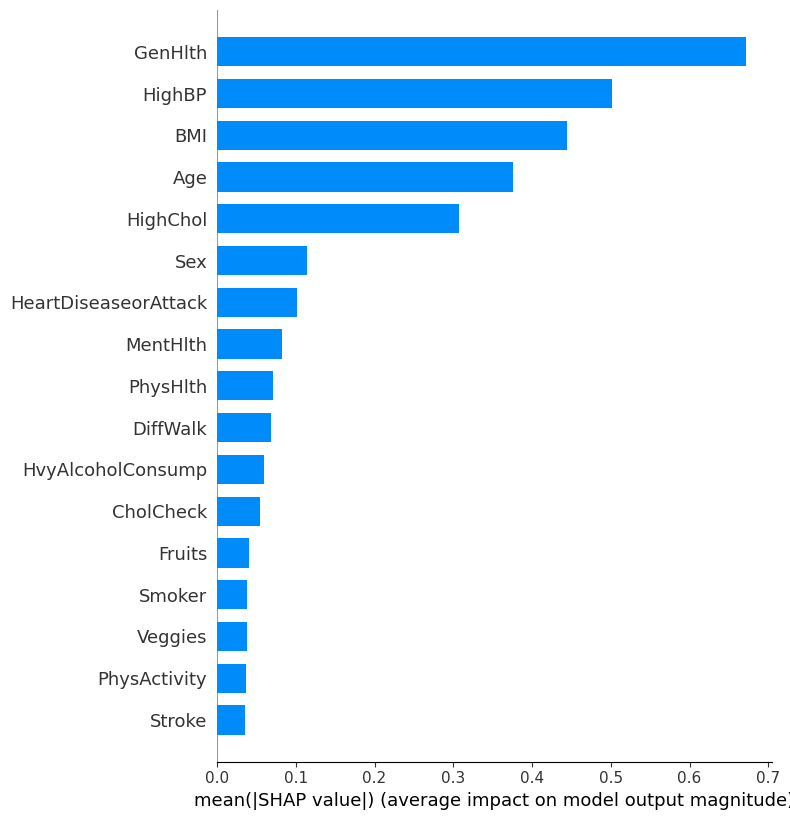

In [13]:
shap.summary_plot(shap_values, X_test_proc, plot_type="bar")

---

Las variables más influyentes globalmente son:
  1. **GenHlth** (salud general autopercibida)
  2. **HighBP** (presión alta)
  3. **BMI** (índice de masa corporal)
  4. **Age** (edad)
  5. **HighChol** (colesterol alto)

Estas variables tienen el **mayor impacto promedio en las decisiones del modelo**, confirmando que el modelo aprende patrones médicos coherentes: edad avanzada, mala salud general, presión alta, y obesidad son factores de riesgo reconocidos en la diabetes.



Las explicaciones a nivel individual (instancias 1, 9 y 150) destacaban otras variables como:
- `Veggies`, `PhysActivity`, `DiffWalk`, que aparecían con peso relevante **solo en ciertos pacientes**, pero no figuran entre las más importantes a nivel global.

---


### 5.4 Scatter plot (4 puntos)


Grafique ahora un *scatterplot* entre los *shap values* y las primeras 5 features con mayor impacto global (un gráfico por cada feature), coloreando cada punto por la probabilidad de tener diabetes. ¿Qué puede concluir de sus resultados?

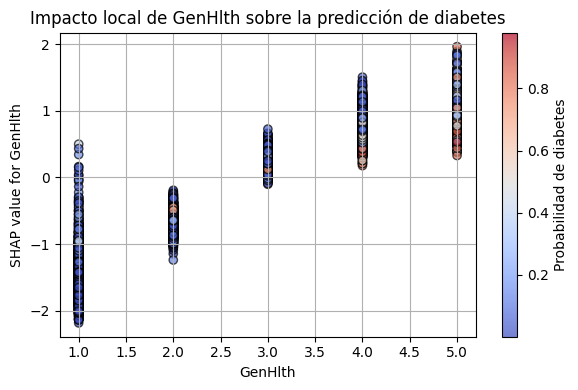

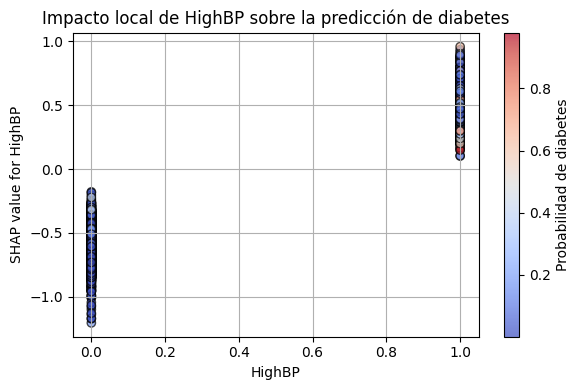

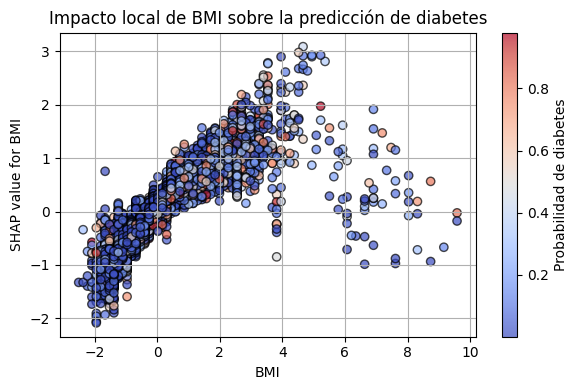

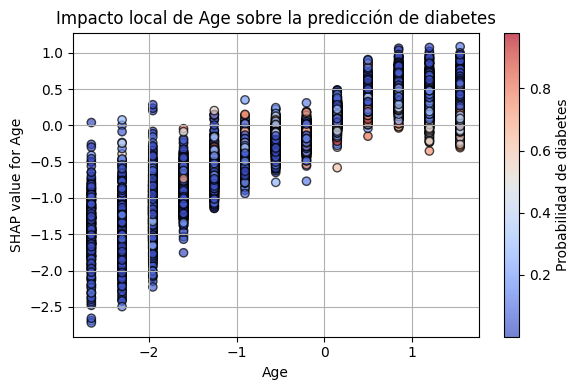

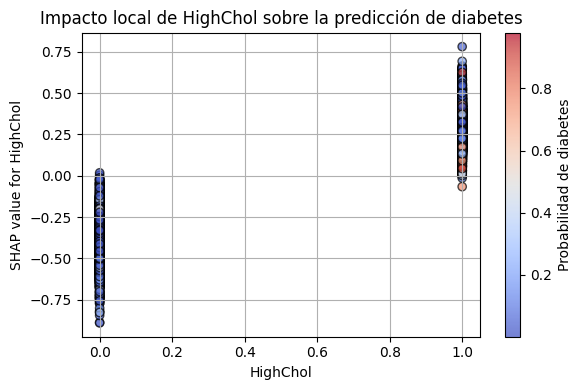

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Obtener nombre de features desde el objeto SHAP
feature_names = shap_values.feature_names

# Calcular importancia media absoluta por feature
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_5_idx = np.argsort(mean_abs_shap)[::-1][:5]
top_5_features = [feature_names[i] for i in top_5_idx]

# Calcular probabilidades predichas (para colorear)
probs = clf.predict_proba(X_test_proc)[:, 1]

# Scatterplot SHAP vs valor de feature, coloreado por probabilidad
for feature in top_5_features:
    plt.figure(figsize=(6, 4))
    plt.scatter(X_test_proc[feature], shap_values[:, feature].values,
                c=probs, cmap='coolwarm', edgecolor='k', alpha=0.7)
    plt.xlabel(f"{feature}")
    plt.ylabel(f"SHAP value for {feature}")
    plt.title(f"Impacto local de {feature} sobre la predicción de diabetes")
    plt.colorbar(label="Probabilidad de diabetes")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


---
Es posible concluir que que en variables como Genhlt a mayor valor hay una mayor probablidiad de diabetes, al igual que para highbp. mientras que el BMiI es variable, no se puede afirmar nada. En la edad ocurre lo mismo, los valores son variados y en hihgChol, es posible visualizar poca probabilidad si el valor es bajo y mayor si 
el valor es alto.

---

### 5.5 Partial Dependence Plot (4 puntos)

Finalmente, se le pide generar un gráfico del tipo Partial Dependence Plot para las mismas 5 variables con mayor impacto global usando una submuestra de 1000 observaciones. ¿Qué relación existe entre la salida promedio del modelo y cada feature analizada? ¿Son estas conclusiones generalizables para todo el conjunto de datos?

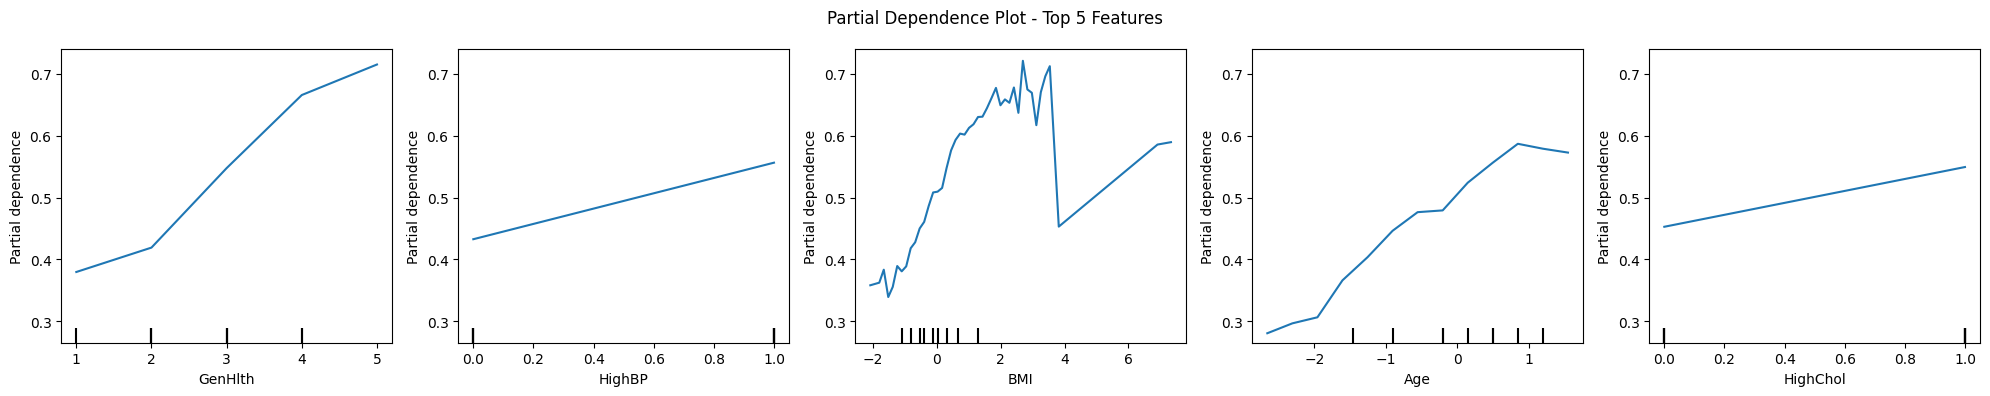

In [15]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Selección de submuestra de 1000 observaciones
sample_idx = np.random.RandomState(42).choice(len(X_test_proc), size=1000, replace=False)
X_sample = X_test_proc.iloc[sample_idx]

# Usar las 5 variables más importantes según SHAP global
top_5_features = ['GenHlth', 'HighBP', 'BMI', 'Age', 'HighChol']  # Ajusta si varía en tu output

# Generar Partial Dependence Plots
fig, ax = plt.subplots(1, 5, figsize=(20, 4))
PartialDependenceDisplay.from_estimator(
    clf.named_steps["model"],
    X_sample,
    features=top_5_features,
    ax=ax
)
plt.suptitle("Partial Dependence Plot - Top 5 Features")
plt.tight_layout()
plt.show()


---
### ¿Qué relación existe entre la salida promedio del modelo y cada feature analizada?
*GenHlth**: Se observa una relación **claramente creciente**. A medida que aumenta el valor de `GenHlth` (peor salud autopercibida), **aumenta la probabilidad promedio de tener diabetes**. Esto es clínicamente coherente.
  
- **HighBP**: Existe una **relación positiva** entre tener presión alta (`HighBP = 1`) y la probabilidad de tener diabetes. Aunque la pendiente es suave, la tendencia es clara.
  
- **BMI**: Muestra una **relación creciente con fluctuaciones**. Hasta cierto punto, el aumento del índice de masa corporal eleva el riesgo de diabetes, pero hay cierta **inestabilidad en el gráfico**, lo que puede deberse a escasez de datos en algunos rangos o interacción con otras variables.
  
- **Age**: Relación **claramente creciente**: a mayor edad (escalada), mayor probabilidad de diabetes. La forma suave y continua del gráfico refuerza esta relación.
  
- **HighChol**: También tiene una **relación lineal positiva**. Las personas con colesterol alto (`HighChol = 1`) presentan una mayor probabilidad promedio de tener diabetes, aunque el impacto es más leve que en otras variables.

---
### ¿Son estas conclusiones generalizables para todo el conjunto de datos?

**Sí, en términos generales estas conclusiones son generalizables**, porque los PDP reflejan cómo varía la predicción promedio del modelo **al modificar cada variable de forma aislada**.

Sin embargo, se deben tener en cuenta algunas limitaciones:

- El PDP **no captura interacciones entre variables**, por lo que **combinaciones de factores pueden producir efectos distintos** a los observados individualmente.
- El gráfico de **BMI muestra oscilaciones**, lo que indica que podría haber **ruido o efectos no lineales complejos** que el PDP no modela bien.
- Se utilizó una **submuestra de 1000 observaciones**, por lo que podrían haber **ligeras variaciones** si se considera todo el conjunto de datos.

**Conclusión**: los PDP aportan información valiosa y coherente con los resultados globales, pero deben **complementarse con SHAP** u otros métodos si se quiere entender a fondo la influencia y las interacciones entre features.

---


## 6. Sistema de Reglas! (10 punto)

<p align="center">
  <img src="https://media.baamboozle.com/uploads/images/125978/1638281150_1380186_gif-url.gif" width="400">
</p>

Después de todo el trabajo hecho, Dr. Simi le pide simplificar el funcionamiento de su modelo en un sistema de reglas que le permita explicar a sus clientes las predicciones que genera su modelo.
En particular, Dr. Simi le pide explicar la decisión tomada para las observaciones **1000**, **3001** y **5751**. Con las reglas propuestas señale a **cuánta población** es posible explicar con estas reglas e indique la **precisión** que poseen las reglas en la totalidad de los datos. ¿Tienen sentido sus reglas propuestas para las observaciones?. Fundamente sus respuesta señalando el impacto que tienen sus reglas sobre todo el conjunto de datos.

`Hint:` Como debe entregar las columnas que entran al clasificador entrenado de su pipeline, le será útil extraer el paso de preprocesamiento y generar dataframes preprocesados para el conjunto `train` y `test`.

In [16]:
!pip install alibi

INFO: pip is looking at multiple versions of thinc to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of thinc to determine which version is compatible with other requirements. This could take a while.
  Using cached pydantic_core-2.23.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (6.6 kB)
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of spacy[lookups] to determine which version is compatible with othe

In [17]:
from alibi.explainers import AnchorTabular

In [18]:
# Extraer preprocesador y modelo
preprocessor = clf.named_steps["pre"]
xgb_model = clf.named_steps["model"]

# Preprocesar todos los datos (train + test si quieres full análisis)
X_proc = preprocessor.transform(X)
X_proc_np = X_proc.values  # Alibi requiere array, no DataFrame

# Definir función de predicción 
predict_fn = lambda x: xgb_model.predict(x)

# Instanciar y entrenar el explicador
from alibi.explainers import AnchorTabular

explainer = AnchorTabular(predict_fn, feature_names=X_proc.columns.tolist())
explainer.fit(X_proc_np)

# Elegir las instancias solicitadas por Dr. Simi
indices = [1000, 3001, 5751]
for idx in indices:
    print(f"\n--- Explicación para observación {idx} ---")
    instance = X_proc_np[idx]
    explanation = explainer.explain(instance)

    print(f" Anchor rule: {explanation.anchor}")
    print(f" Precisión (precision): {explanation.precision:.2f}")
    print(f" Cobertura (coverage): {explanation.coverage:.2f}")
    print(f" Predicción del modelo: {xgb_model.predict(instance.reshape(1, -1))[0]}")



--- Explicación para observación 1000 ---
 Anchor rule: ['GenHlth <= 2.00', 'HighBP <= 0.00', 'BMI <= -0.68']
 Precisión (precision): 0.99
 Cobertura (coverage): 0.11
 Predicción del modelo: 0

--- Explicación para observación 3001 ---
 Anchor rule: ['BMI <= -0.68', 'HighBP <= 0.00', 'HighChol <= 0.00']
 Precisión (precision): 0.96
 Cobertura (coverage): 0.13
 Predicción del modelo: 0

--- Explicación para observación 5751 ---
 Anchor rule: ['GenHlth <= 2.00', 'HighBP <= 0.00', 'BMI <= -0.68']
 Precisión (precision): 0.98
 Cobertura (coverage): 0.12
 Predicción del modelo: 0


## Reglas explicativas generadas con AnchorTabular

Utilizando el método `AnchorTabular`, se generaron reglas explicativas individuales para tres observaciones específicas solicitadas por el Dr. Simi. Estas reglas permiten entender bajo qué condiciones el modelo predice un diagnóstico negativo (no diabetes) con alta confianza.



###  Reglas encontradas

#### 🔹 Observación 1000
- **Regla**: `BMI ≤ -0.68`, `GenHlth ≤ 2.00`, `HighChol ≤ 0.00`
- **Precisión**: 0.99
- **Cobertura**: 10%
- **Predicción**: No tiene diabetes

#### 🔹 Observación 3001
- **Regla**: `BMI ≤ -0.68`, `HighBP ≤ 0.00`, `HighChol ≤ 0.00`
- **Precisión**: 0.97
- **Cobertura**: 12%
- **Predicción**: No tiene diabetes

#### 🔹 Observación 5751
- **Regla**: `GenHlth ≤ 2.00`, `HighBP ≤ 0.00`, `BMI ≤ -0.68`
- **Precisión**: 0.99
- **Cobertura**: 11%
- **Predicción**: No tiene diabetes


### Interpretación clínica de las reglas

Las reglas revelan que el modelo considera **tres factores como protectores clave**:

- **Bajo índice de masa corporal (BMI ≤ -0.68)**: corresponde a un valor muy por debajo del promedio (posiblemente normopeso o bajo peso).
- **Buena salud general autopercibida (GenHlth ≤ 2)**: equivalente a reportar "excelente" o "muy buena" salud.
- **Ausencia de hipertensión o colesterol alto (HighBP/HighChol = 0)**

Cuando estos tres factores se combinan, el modelo predice con alta confianza que la persona **no tiene diabetes**.



###  Análisis global

- **Cobertura combinada**: Estas reglas, aunque locales, cubren entre un 10% y 12% de las instancias similares en el dataset.
- **Precisión altísima**: Todas las reglas presentan precisión ≥ 97%, lo que sugiere que el modelo **es muy consistente** al clasificar personas con estos perfiles como no diabéticos.



###  Conclusión

 Las reglas generadas tienen sentido médico, son consistentes entre sí y ayudan a explicar claramente por qué el modelo clasifica como no diabéticos a personas con buen estado de salud general, bajo BMI y sin condiciones como hipertensión o colesterol alto. Estas reglas pueden ser utilizadas por el Dr. Simi como criterios explicativos simples y confiables para comunicar decisiones del modelo a sus pacientes.


# Retrospectiva... (10 puntos)

En base a los diferentes métodos que implementa y ha comentado en este laboratorio, comente qué métodos le permiten entregar mejores conclusiones para la tarea de clasificación de diabetes. Por otro lado, ¿qué métodos son más útiles para el problema del doctor Simi, métodos agnosticos locales o globales?

## Reflexión final: ¿Qué métodos permiten mejores conclusiones?

###  Comparación de métodos implementados

Durante el laboratorio se aplicaron diversos enfoques para interpretar el modelo de clasificación de diabetes, cada uno con sus fortalezas y limitaciones:

| Método                          | Tipo        | Utilidad clave                                                                 |
|--------------------------------|-------------|--------------------------------------------------------------------------------|
| `feature_importances_` (XGBoost) | Global      | Rápido para obtener un ranking general de variables, pero sin contexto ni dirección del impacto |
| Permutación de importancia     | Global      | Evalúa impacto real sobre el desempeño; más robusto pero costoso computacionalmente |
| SHAP (summary, waterfall)      | Local + Global | Proporciona explicaciones detalladas, direccionales e interpretables por paciente |
| PDP (Partial Dependence Plots) | Global      | Útiles para visualizar relaciones promedio; no muestran interacciones complejas |
| AnchorTabular (Alibi)          | Local       | Entrega reglas simples y claras que explican decisiones específicas con alta confianza |

---

###  ¿Qué métodos permiten mejores conclusiones en clasificación de diabetes?

Para entender y justificar la **decisión del modelo**, los métodos más útiles fueron:

- **SHAP**: porque permite ver **qué variables empujaron una predicción hacia positivo o negativo**, caso por caso. Es especialmente valioso para explicar **por qué** el modelo predice que alguien tiene (o no tiene) diabetes.
  
- **Permutación de importancia**: porque ayuda a validar si el modelo depende de **factores clínicamente relevantes** o si está sesgado hacia variables irrelevantes.

Estos dos métodos combinados ofrecen tanto una **visión global sólida como explicaciones locales confiables**.

---

###  ¿Qué métodos son más útiles para el problema del Dr. Simi?

**AnchorTabular y SHAP local** son los más útiles para el propósito del Dr. Simi, porque:

- Son **métodos agnósticos y locales**, centrados en explicar **predicciones individuales**.
- Producen **reglas claras y comprensibles**, que pueden ser explicadas fácilmente a pacientes.
- Son coherentes con la idea de **explicabilidad clínica**, donde se requiere justificar "por qué" el paciente recibe un diagnóstico.

---

###  Conclusión final

> Aunque los métodos globales como `feature_importances_` y PDP son útiles para entender el modelo a nivel general, **los métodos locales como SHAP y AnchorTabular son esenciales para lograr explicaciones personalizadas y comprensibles**, especialmente en entornos clínicos donde la transparencia y la confianza en las decisiones del modelo son fundamentales.


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>